In [65]:
from cil.framework import AcquisitionData, AcquisitionGeometry
from cil.io.TIFF import TIFFStackReader
import warnings
import numpy as np
import os
from pathlib import Path, PureWindowsPath
from cil.utilities.display import show2D, show_geometry, show_system_positions
from cil.framework import ImageGeometry
# from cil.plugins.astra import ProjectionOperator, FDK_Flexible
    
# Rewrite
class NSIDataReader(object):
    
    def __init__(self, 
                 **kwargs):
        '''Basic reader for xtekct files
        
        Parameters
        ----------

            
        file_name: str with full path to file. TIFFs will be retrieved from the same path.
            
        roi: dictionary with roi to load 
                {'angle': (start, end, step), 
                 'horizontal': (start, end, step), 
                 'vertical': (start, end, step)}
                Files are stacked along axis_0. axis_1 and axis_2 correspond
                to row and column dimensions, respectively.
                Files are stacked in alphabetic order. 
                To skip projections or to change number of projections to load, 
                adjust 'angle'. For instance, 'angle': (100, 300)
                will skip first 100 projections and will load 200 projections.
                'angle': -1 is a shortcut to load all elements along axis.
                Start and end can be specified as None which is equivalent 
                to start = 0 and end = load everything to the end, respectively.
                Start and end also can be negative.
            
        normalise: bool, normalises loaded projections by detector 
                white level (I_0). Default value is True
                            
        fliplr: bool, default = False, flip projections in the left-right direction
                (about vertical axis)
                            
        mode: str, 'bin' (default) or 'slice'. In bin mode, 'step' number
                of pixels is binned together, values of resulting binned
                pixels are calculated as average. 
                In 'slice' mode 'step' defines standard numpy slicing.
                Note: in general 
                output array size in bin mode != output array size in slice mode
        
        Output
        ------
        
        Acquisition data with corresponding geometry, arranged as ['angle', horizontal'] 
        if a single slice is loaded and ['vertical, 'angle', horizontal'] 
        if more than 1 slices are loaded.
                    
        '''
        
        self.file_name = kwargs.get('file_name', None)
        self.normalise = kwargs.get('normalise', True)
        self.mode = kwargs.get('mode', 'bin')
        self.fliplr = kwargs.get('fliplr', False)
    
    def parse_nsipro(self, file_name):
        with open(file_name, 'r') as f:
            text = f.read()
        lines = [line.rstrip() for line in text.splitlines() if line.strip()]
        root = {}
        stack = [(root, None)]  # (current_dict, current_key)
        
        for line in lines:
            indent = len(line) - len(line.lstrip())
            content = line.strip()
            
            # Adjust stack based on indentation
            while len(stack) > indent // 2 + 1:  # assuming 2 spaces per indent
                stack.pop()
            
            current_dict, current_key = stack[-1]
            
            if content.startswith("</"):  # closing tag
                continue
            
            if content.startswith("<") and ">" in content:
                # Extract tag and value
                tag = content[1:content.find(">")]
                value = content[content.find(">")+1:].strip()
                
                if value:  # tag with value
                    current_dict[tag] = value
                else:  # tag without value (container)
                    if tag in current_dict:
                        # Convert to list if repeated
                        if not isinstance(current_dict[tag], list):
                            current_dict[tag] = [current_dict[tag]]
                        new_dict = {}
                        current_dict[tag].append(new_dict)
                    else:
                        new_dict = {}
                        current_dict[tag] = new_dict
                    stack.append((new_dict, tag))
        
        return root

    def set_up(self, 
               file_name = None, 
               num_proj_subset=None,
               normalise = True,
               mode = 'bin',
               fliplr = False):
        
        self._metadata = self.parse_nsipro(file_name)['NSI Reconstruction Project']
        self.file_name = file_name
        self.num_proj_subset = num_proj_subset
        self.normalise = normalise
        self.mode = mode
        self.fliplr = fliplr
        self.tiff_directory_path = (Path(file_name).parent / PureWindowsPath(self._metadata['Object Radiograph']['file'])).parent
        print(self.tiff_directory_path)

        if self.file_name == None:
            raise Exception('Path to file is required.')
        
        # check if data file exists
        if not(os.path.isfile(self.file_name)):
            raise Exception('File\n {}\n does not exist.'.format(self.file_name))
        
        self._height_per_rev = float(self._metadata['VorteX']['pitch'])
        self._revs = int(self._metadata['VorteX']['revolutions'])
        self._num_proj = int(self._metadata['Object Radiograph']['number'])
        self._angle_step = self._num_proj / (360 * self._revs)
        self._proj_per_rev = self._num_proj / self._revs
        self._height_per_step = self._height_per_rev / self._proj_per_rev

        self._roi = {'axis_0': (None, self.num_proj_subset, None), 'axis_1': -1, 'axis_2': -1}
        tiff_reader = TIFFStackReader(file_name=self.tiff_directory_path, roi=self._roi)

        self._arr = tiff_reader.read()

        self._pixel_num_w = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['width pixels'])
        self._pixel_num_h = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['height pixels'])
        microns_to_mm = 0.001
        self._pixel_size_w = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel width microns'])
        self._pixel_size_h = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel height microns'])
        self._src_to_det = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to detector distance'])
        self._src_to_obj = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to table distance'])
        self._obj_to_det = self._src_to_obj - self._src_to_det

        self.N = num_proj_subset if num_proj_subset else self._num_proj
        self._src_pos = np.zeros((self.N,3))
        self._det_pos = np.zeros((self.N,3))
        self._det_x = np.zeros((self.N,3))
        self._det_y = np.zeros((self.N,3))

        self._src_pos[0] = [self._src_to_obj, 0., 0.]
        self._det_pos[0] = [self._obj_to_det, 0., 0.]
        self._det_x[0] = [0., 1, 0]
        self._det_y[0] = [0., 0., 1]
        for i in range(1,self.N):
            h = i * self._height_per_step
            ang = self._angle_step
            ang_rad = np.deg2rad(ang)

            c = np.cos(ang_rad)                # cosine of the angle
            s = np.sin(ang_rad)                # sine of the angle

            Rz = np.array([
                [ c, -s, 0],                     # first row: x-axis transformation
                [ s,  c, 0],                     # second row: y-axis transformation
                [ 0,  0, 1]                      # third row: z-axis remains unchanged
            ])
            self._src_pos[i] = Rz @ self._src_pos[i-1]
            self._det_pos[i] = Rz @ self._det_pos[i-1]
            self._det_x[i] = Rz @ self._det_x[i-1]
            self._det_y[i] = Rz @ self._det_y[i-1]

            
            self._src_pos[i,2] = h
            self._det_pos[i,2] = h
        
        self._ag = AcquisitionGeometry.create_Cone3D_Flex(self._src_pos, self._det_pos, self._det_x, self._det_y)
        # self._ag = self._ag.set_angles(np.arange(0,self.N+self._angle_step,self._angle_step))
        self._ag = self._ag.set_panel((self._pixel_num_w, self._pixel_num_h), (self._pixel_size_w, self._pixel_size_h))
        self._ad = AcquisitionData(array=self._arr, geometry=self._ag)

        self._ig = ImageGeometry(
            self._pixel_num_w, self._pixel_num_w, self.N,
            self._pixel_size_w, self._pixel_size_w,
            (self._height_per_rev * self._revs / self._num_proj) * (self.N/self._num_proj)
        )

    def get_geometry(self):
        
        '''
        Return AcquisitionGeometry object
        '''
        
        return self._ag
    def get_roi(self):
        '''returns the roi'''
        roi = self._roi_par[:]
        if self._ag.dimension == '2D':
            roi.pop(1)

        roidict = {}
        for i,el in enumerate(roi):
            # print (i, el)
            roidict['axis_{}'.format(i)] = tuple(el)
        return roidict

    def read(self):
        
        '''
        Reads projections and return AcquisitionData container
        '''
        
        reader = TIFFStackReader()

        roi = self.get_roi()

        reader.set_up(file_name=self.tiff_directory_path,
                      roi=roi, mode=self.mode)

        ad = reader.read_as_AcquisitionData(self._ag)
              
        if (self.normalise):
            #ad.array[ad.array < 1] = 1
            # cast the data read to float32
            ad = ad / np.float32(float(1))
            
        
        if self.fliplr:
            dim = ad.get_dimension_axis('horizontal')
            ad.array = np.flip(ad.array, dim)
        
        return ad

In [66]:
def parse_nsipro(file_name):
        with open(file_name, 'r') as f:
            text = f.read()
        lines = [line.rstrip() for line in text.splitlines() if line.strip()]
        root = {}
        stack = [(root, None)]  # (current_dict, current_key)
        
        for line in lines:
            indent = len(line) - len(line.lstrip())
            content = line.strip()
            
            # Adjust stack based on indentation
            while len(stack) > indent // 2 + 1:  # assuming 2 spaces per indent
                stack.pop()
            
            current_dict, current_key = stack[-1]
            
            if content.startswith("</"):  # closing tag
                continue
            
            if content.startswith("<") and ">" in content:
                # Extract tag and value
                tag = content[1:content.find(">")]
                value = content[content.find(">")+1:].strip()
                
                if value:  # tag with value
                    current_dict[tag] = value
                else:  # tag without value (container)
                    if tag in current_dict:
                        # Convert to list if repeated
                        if not isinstance(current_dict[tag], list):
                            current_dict[tag] = [current_dict[tag]]
                        new_dict = {}
                        current_dict[tag].append(new_dict)
                    else:
                        new_dict = {}
                        current_dict[tag] = new_dict
                    stack.append((new_dict, tag))
        
        return root

In [67]:
from pathlib import Path
BASE_PATH = Path("/work3/s164564/CIL-Reader-Showcase/data/NSI-data")
FILE_NAME = "Demo_BabeRuth - PreReconstruction.nsipro"
DATA_PATH = BASE_PATH / FILE_NAME

In [68]:
metadata = parse_nsipro(DATA_PATH)
metadata

{'NSI Reconstruction Project': {'version': '2.0',
  'Project Name': 'Demo_BabeRuth',
  'Project Folder': 'Z:\\Training\\Demo_BabeRuth',
  'Creation Date': '11/5/2024 11:28:36 AM',
  'Comments': 'Helical Step scan completed at 11/5/2024 2:18:36 PM',
  'VorteX': {'height': '180.13045',
   'pitch': '15.0108708333333',
   'revolutions': '12',
   'sets': '3',
   'set height': '60.0434833333333',
   'revolutions per set': '4',
   'sigma': '50.0362361111111'},
  'Object Radiograph': {'file': 'Radiographs-Demo_BabeRuth\\Demo_BabeRuth-radio*.tif',
   'pitch': '0.2 0.2',
   'sort numerically': 'True',
   'number': '4320',
   'angleStep': '0.999306037473976'},
  'Correction': {'already masked': 'False',
   'flipH': 'False',
   'flipV': 'False',
   'rotate': '0',
   'crop': '40 40 40 40'},
  'Geometry Correction Steps': {'center': '0 0.0417065177124334 0',
   'source': '0 0.0417065177124334 0',
   'reference': '0 0.0417065177124334 0',
   'normal': '0 0 0',
   'horizontal': '0 0 0'},
  'CT Project

In [69]:
reader = NSIDataReader(file_name=DATA_PATH)

In [70]:
reader.set_up(file_name=DATA_PATH, num_proj_subset=720)

/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Radiographs-Demo_BabeRuth


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_paths(coords1, coords2):
    """
    Plots two 3D paths from (N,3) NumPy arrays.
    """

    # Extract components for the first path
    x1 = coords1[:, 0]      # First path: x-values
    y1 = coords1[:, 1]      # First path: y-values
    z1 = coords1[:, 2]      # First path: z-values

    # Extract components for the second path
    x2 = coords2[:, 0]      # Second path: x-values
    y2 = coords2[:, 1]      # Second path: y-values
    z2 = coords2[:, 2]      # Second path: z-values

    # Set up the figure and 3D axis
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot both paths
    ax.plot(x1, y1, z1)     # First path
    ax.plot(x2, y2, z2)     # Second path

    # Labels for clarity
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.show()


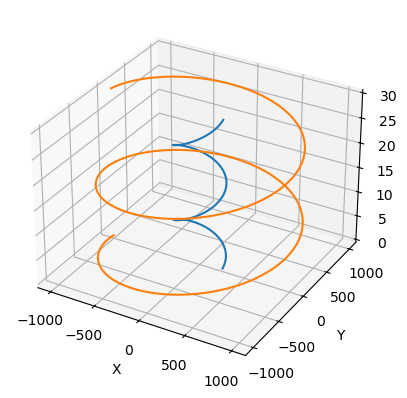

In [72]:
plot_3d_paths(reader._src_pos, reader._det_pos)

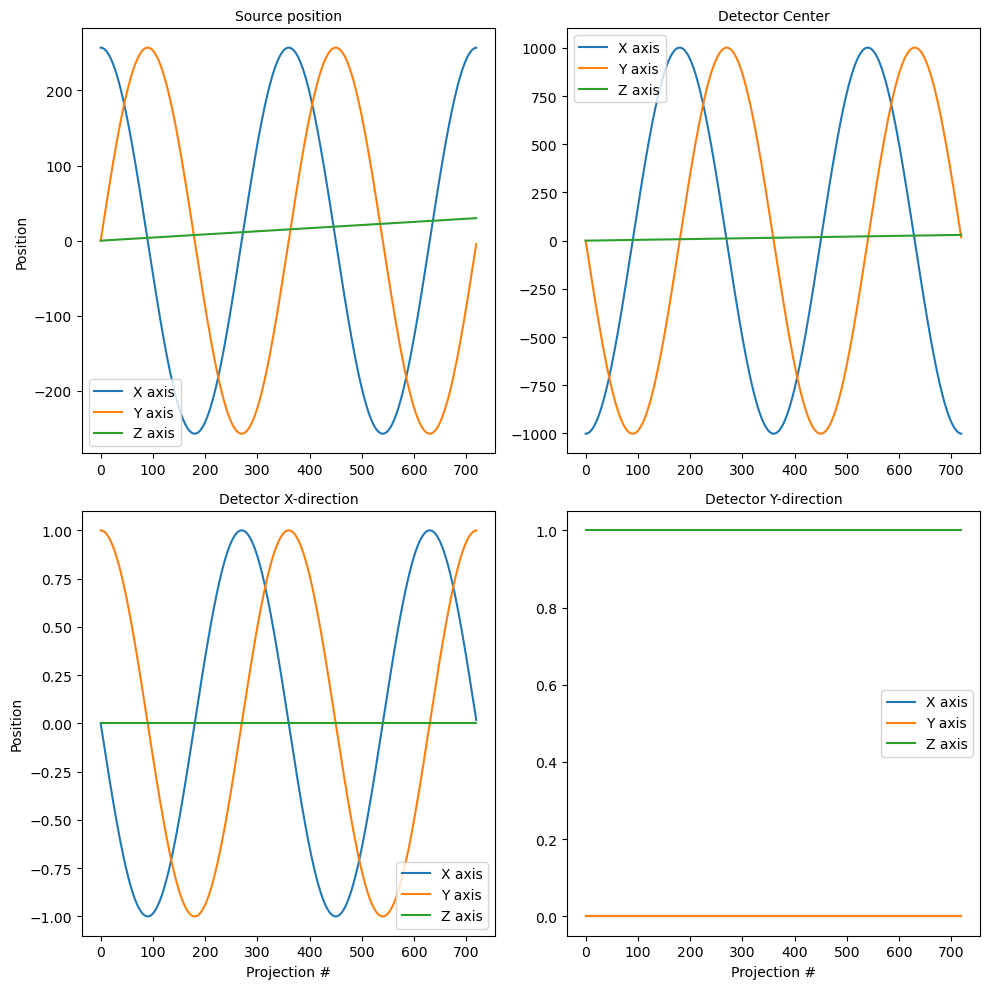

In [73]:
show_system_positions(reader._ag)

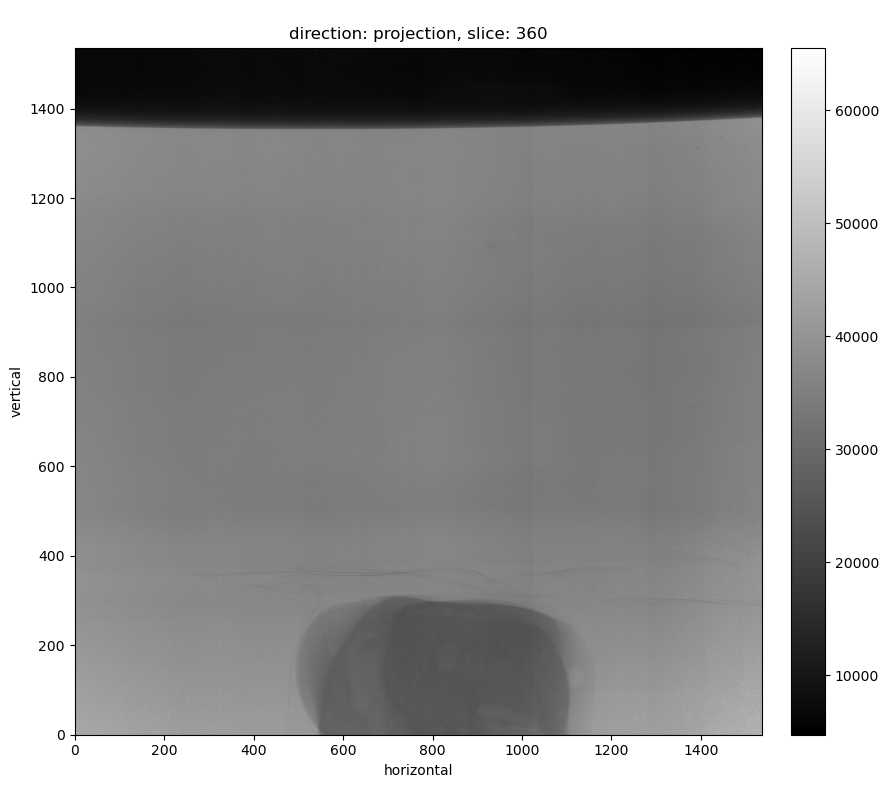

In [74]:
show2D(reader._ad)

In [75]:
reader._ad.max()

65534.0

(array([7.98312200e+06, 6.16578340e+07, 5.99689620e+07, 1.76655660e+07,
        8.53078200e+06, 5.42639500e+06, 3.99108800e+06, 3.15165000e+06,
        2.57293800e+06, 2.14696400e+06, 1.85766800e+06, 1.63888700e+06,
        1.65291200e+06, 3.66479800e+06, 9.20154300e+06, 1.41050760e+07,
        1.95495480e+07, 2.06514900e+07, 1.58881180e+07, 1.20989530e+07,
        9.13013800e+06, 9.01028200e+06, 2.13779270e+07, 1.12165298e+08,
        3.17212489e+08, 3.69414556e+08, 2.40801075e+08, 1.33363174e+08,
        8.12138950e+07, 5.82717590e+07, 3.93096010e+07, 2.02813080e+07,
        8.72886100e+06, 3.28310000e+06, 9.13415000e+05, 3.30742000e+05,
        1.77428000e+05, 1.03416000e+05, 6.53990000e+04, 4.15350000e+04,
        2.51770000e+04, 1.79010000e+04, 1.21260000e+04, 7.77400000e+03,
        6.49300000e+03, 5.89100000e+03, 4.61300000e+03, 3.05400000e+03,
        1.99600000e+03, 8.40300000e+03]),
 array([ 3914.        ,  5146.39990234,  6378.79980469,  7611.20019531,
         8843.59960938

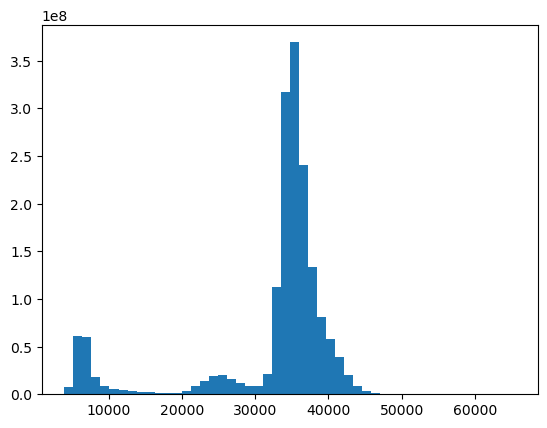

In [76]:
plt.hist(reader._ad.as_array().ravel(), bins=50)

In [77]:
from cil.plugins.tigre import ProjectionOperator

In [78]:
from cil.plugins.astra import FBP

In [79]:
ag = reader._ag
ad = reader._ad
ig = reader._ig

In [82]:
ad.reorder(order='astra')
fbp = FBP(image_geometry=ig, acquisition_geometry=ad.geometry)
fbp.set_input(ad)
recon = fbp.get_output()

Configuration Error in CUDA_FDK: Voxels must be cubes for FDK


Exception: Unable to initialize Algorithm.